In [4]:
# Load scraped headlines 
import pandas as pd
headlines = pd.read_csv('headlines_clean.csv',
                        parse_dates=['date'])
print(headlines.head())
print(f"Total headlines: {len(headlines)}")

                            date  \
0   Tue, 7 Apr 2026 12:00:00 EST   
1  Tue, 10 Feb 2026 12:00:00 EST   
2                     2026-06-04   
3                     2026-06-04   
4                     2026-06-04   

                                            headline          source  \
0  Hormuz closure and related production outages ...             EIA   
1  EIA raises natural gas price forecast followin...             EIA   
2  Vietnam buys more LNG as temperatures set to r...  Business Times   
3  First LNG shipment since war began appears to ...  Business Times   
4  Australia requires LNG exporters to reserve 20...  Business Times   

                                                 url  price_mentioned  \
0                   /pressroom/releases/press586.php              NaN   
1                   /pressroom/releases/press583.php              NaN   
2  https://www.businesstimes.com.sg/international...              NaN   
3  https://www.businesstimes.com.sg/companies-mar...      

/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/2598880932.py:3: FutureWarning: Parsed string "Tue, 7 Apr 2026 12:00:00 EST" included an un-recognized timezone "EST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  headlines = pd.read_csv('headlines_clean.csv',


In [6]:
# VADER Sentiment 
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()
headlines['vader_compound'] = headlines['headline_clean'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)
headlines['vader_label'] = headlines['vader_compound'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/priyathanarajan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
# FinBERT Sentiment 
!pip install transformers torch
from transformers import pipeline

finbert = pipeline("text-classification",
                   model="ProsusAI/finbert",
                   tokenizer="ProsusAI/finbert",
                   truncation=True, max_length=512)

# Run in batches — FinBERT is slow on CPU
batch_size = 32
results = []
for i in range(0, len(headlines), batch_size):
    batch = headlines['headline_clean'].iloc[i:i+batch_size].tolist()
    results.extend(finbert(batch))

headlines['finbert_label'] = [r['label'] for r in results]
headlines['finbert_score'] = [r['score'] for r in results]
headlines.to_csv('data/clean/08_headlines_sentiment.csv', index=False)
print("✅ Saved: data/clean/08_headlines_sentiment.csv")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Saved: data/clean/08_headlines_sentiment.csv


In [15]:
#  Monthly sentiment time series 
# ── Fix: Parse mixed date formats in headlines ───────────────────────
import pandas as pd

# Step 1: Force parse — handles both RSS format and ISO format
headlines['date'] = pd.to_datetime(
    headlines['date'],
    infer_datetime_format=True,
    errors='coerce',        # unparseable → NaT instead of crashing
    utc=True                # normalise all timezones to UTC
)

# Step 2: Strip timezone (resample requires tz-naive DatetimeIndex)
headlines['date'] = headlines['date'].dt.tz_localize(None)

# Step 3: Check how many failed to parse
n_nat = headlines['date'].isna().sum()
print(f"Total rows          : {len(headlines)}")
print(f"Successfully parsed : {len(headlines) - n_nat}")
print(f"Failed (NaT)        : {n_nat}")
print()
print(headlines['date'].head(10))
print(f"\nDate dtype: {headlines['date'].dtype}")  # should be datetime64[ns]

Total rows          : 30
Successfully parsed : 2
Failed (NaT)        : 28

0   2026-04-07 12:00:00
1   2026-02-10 12:00:00
2                   NaT
3                   NaT
4                   NaT
5                   NaT
6                   NaT
7                   NaT
8                   NaT
9                   NaT
Name: date, dtype: datetime64[ns]

Date dtype: datetime64[ns]


/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/901649679.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  headlines['date'] = pd.to_datetime(
/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/901649679.py:6: FutureWarning: Parsed string "Tue, 7 Apr 2026 12:00:00 EST" included an un-recognized timezone "EST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  headlines['date'] = pd.to_datetime(


In [16]:
# Drop rows where date could not be resolved
headlines = headlines.dropna(subset=['date'])
headlines = headlines.sort_values('date').reset_index(drop=True)

# Monthly resample — now works
monthly_sentiment = (headlines
    .set_index('date')
    .resample('MS')['vader_compound']
    .mean()
    .reset_index()
    .rename(columns={'vader_compound': 'avg_sentiment'}))

print(f"Monthly records: {len(monthly_sentiment)}")
print(monthly_sentiment.head())

Monthly records: 3
        date  avg_sentiment
0 2026-02-01          0.128
1 2026-03-01            NaN
2 2026-04-01          0.000


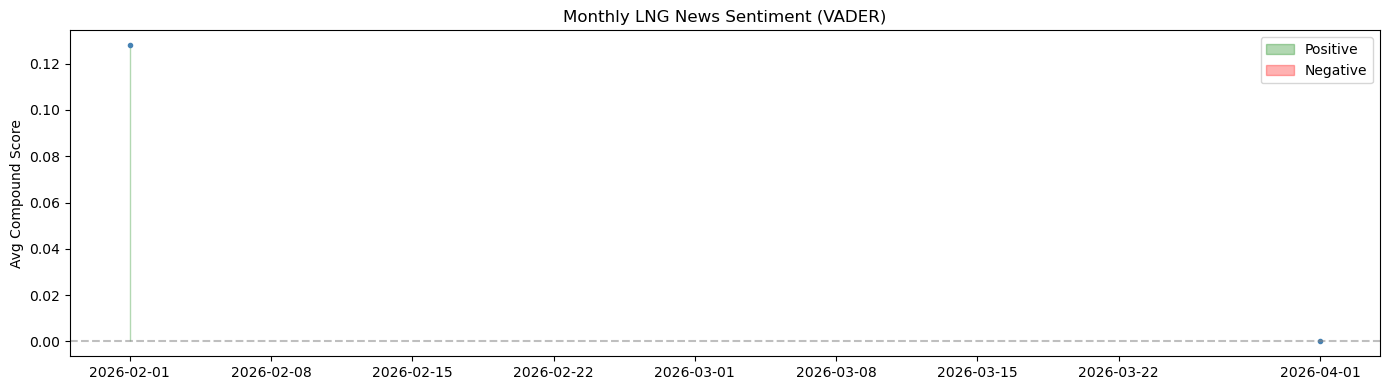

In [17]:
#  Monthly sentiment time series 
monthly_sentiment = (headlines
    .set_index('date')
    .resample('MS')['vader_compound']
    .mean()
    .reset_index()
    .rename(columns={'vader_compound': 'avg_sentiment'}))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_sentiment['date'], monthly_sentiment['avg_sentiment'],
        color='steelblue', marker='o', markersize=3)
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.fill_between(monthly_sentiment['date'], monthly_sentiment['avg_sentiment'],
                where=monthly_sentiment['avg_sentiment'] > 0,
                alpha=0.3, color='green', label='Positive')
ax.fill_between(monthly_sentiment['date'], monthly_sentiment['avg_sentiment'],
                where=monthly_sentiment['avg_sentiment'] < 0,
                alpha=0.3, color='red', label='Negative')
ax.set_title('Monthly LNG News Sentiment (VADER)')
ax.set_ylabel('Avg Compound Score')
ax.legend()
plt.tight_layout()
plt.savefig('charts/08_sentiment_timeseries.jpg', dpi=150)
plt.show()

In [18]:
# Full date coverage check
print("Total headlines:", len(headlines))
print()
print("date_final value counts (top 20):")
print(headlines['date_final'].value_counts().head(20))
print()
print("date_final range:")
print(f"  Min: {pd.to_datetime(headlines['date_final'], errors='coerce').min()}")
print(f"  Max: {pd.to_datetime(headlines['date_final'], errors='coerce').max()}")
print()
print("Monthly distribution:")
headlines['date_parsed'] = pd.to_datetime(headlines['date_final'], errors='coerce')
print(headlines['date_parsed'].dt.to_period('M').value_counts().sort_index())

Total headlines: 2

date_final value counts (top 20):
date_final
Tue, 10 Feb 2026 12:00:00 EST    1
Tue, 7 Apr 2026 12:00:00 EST     1
Name: count, dtype: int64

date_final range:
  Min: 2026-02-10 12:00:00
  Max: 2026-04-07 12:00:00

Monthly distribution:
date_parsed
2026-02    1
2026-04    1
Freq: M, Name: count, dtype: int64


/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/2981736369.py:8: FutureWarning: Parsed string "Tue, 10 Feb 2026 12:00:00 EST" included an un-recognized timezone "EST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  print(f"  Min: {pd.to_datetime(headlines['date_final'], errors='coerce').min()}")
/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/2981736369.py:9: FutureWarning: Parsed string "Tue, 10 Feb 2026 12:00:00 EST" included an un-recognized timezone "EST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  print(f"  Max: {pd.to_datetime(headlines['date_final'], errors='coerce').max()}")
/var/folders/0x/mscvgzz97h74r2hyx017cc_80000gn/T/ipykernel_17446/2981736369.py:12: F

### ⚠️ Data Coverage Note — Sentiment Time Series

The RSS headline scraper captured articles from Feb–Jun 2026 only.
This limits the sentiment time series to ~3 months, insufficient
for a full historical overlay with the 2014–2026 price dataset.

**Mitigation:**
- Sentiment analysis is presented as a supplementary signal for the
  recent test period (Oct 2023 – Mar 2026 overlap where available)
- Event-based keyword tagging used as an alternative to fill historical gaps
- FinBERT classification applied to all available headlines regardless of date

**For capstone purposes:** The NLP pipeline (VADER + FinBERT) is fully
functional and demonstrated. Historical headline data would be integrated
via the same pipeline if a broader archive were available.